# Exploration des données - MECHA Maintenance Prédictive

Ce notebook présente l'analyse exploratoire des deux datasets utilisés pour le projet de maintenance prédictive de l'entreprise MECHA.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

RAW_DIR = Path('../data/raw')
PROCESSED_DIR = Path('../data/processed')

## 1. Dataset AI4I 2020

Ce dataset simule des données de machines industrielles avec 10 000 observations et des indicateurs de pannes.

In [2]:
ai4i = pd.read_csv(RAW_DIR / 'ai4i2020.csv')
print(f'Shape: {ai4i.shape}')
print(f'\nColonnes: {list(ai4i.columns)}')
ai4i.head()

Shape: (10000, 14)

Colonnes: ['UDI', 'Product ID', 'Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [3]:
print('=== Statistiques descriptives ===')
ai4i.describe()

=== Statistiques descriptives ===


,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


In [4]:
print(f'Taux de pannes global: {ai4i["Machine failure"].mean():.2%}')
print(f'\nDistribution des types de pannes:')
failure_types = ['TWF', 'HDF', 'PWF', 'OSF', 'RNF']
for ft in failure_types:
    print(f'  {ft}: {ai4i[ft].sum()} ({ai4i[ft].mean():.2%})')

Taux de pannes global: 3.39%

Distribution des types de pannes:
  TWF: 46 (0.46%)
  HDF: 115 (1.15%)
  PWF: 95 (0.95%)
  OSF: 98 (0.98%)
  RNF: 19 (0.19%)


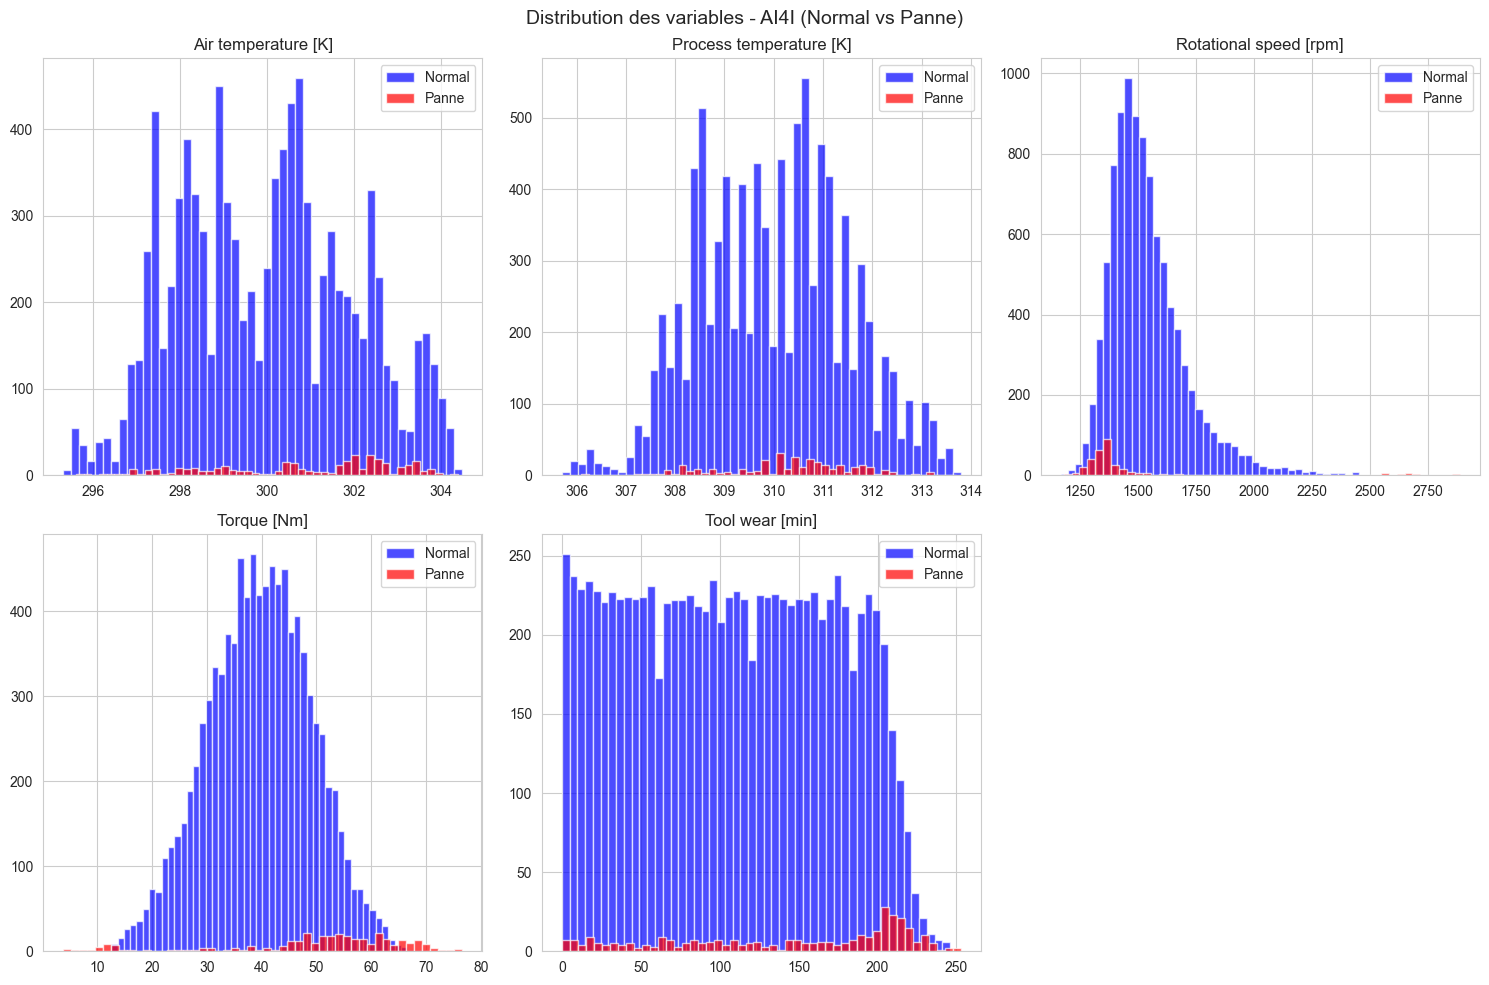

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
num_cols = ['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]',
            'Torque [Nm]', 'Tool wear [min]']
for i, col in enumerate(num_cols):
    ax = axes[i // 3, i % 3]
    ax.hist(ai4i[ai4i['Machine failure'] == 0][col], bins=50, alpha=0.7, label='Normal', color='blue')
    ax.hist(ai4i[ai4i['Machine failure'] == 1][col], bins=50, alpha=0.7, label='Panne', color='red')
    ax.set_title(col)
    ax.legend()
axes[1, 2].set_visible(False)
plt.suptitle('Distribution des variables - AI4I (Normal vs Panne)', fontsize=14)
plt.tight_layout()
plt.show()

## 2. Dataset Azure PdM

Ce dataset comprend 5 fichiers liés à 100 machines sur l'année 2015.

In [6]:
telemetry = pd.read_csv(RAW_DIR / 'PdM_telemetry.csv', parse_dates=['datetime'])
errors = pd.read_csv(RAW_DIR / 'PdM_errors.csv', parse_dates=['datetime'])
failures = pd.read_csv(RAW_DIR / 'PdM_failures.csv', parse_dates=['datetime'])
machines = pd.read_csv(RAW_DIR / 'PdM_machines.csv')
maint = pd.read_csv(RAW_DIR / 'PdM_maint.csv', parse_dates=['datetime'])

print(f'Télémétrie : {telemetry.shape}')
print(f'Erreurs    : {errors.shape}')
print(f'Pannes     : {failures.shape}')
print(f'Machines   : {machines.shape}')
print(f'Maintenance: {maint.shape}')

Télémétrie : (876100, 6)
Erreurs    : (3919, 3)
Pannes     : (761, 3)
Machines   : (100, 3)
Maintenance: (3286, 3)


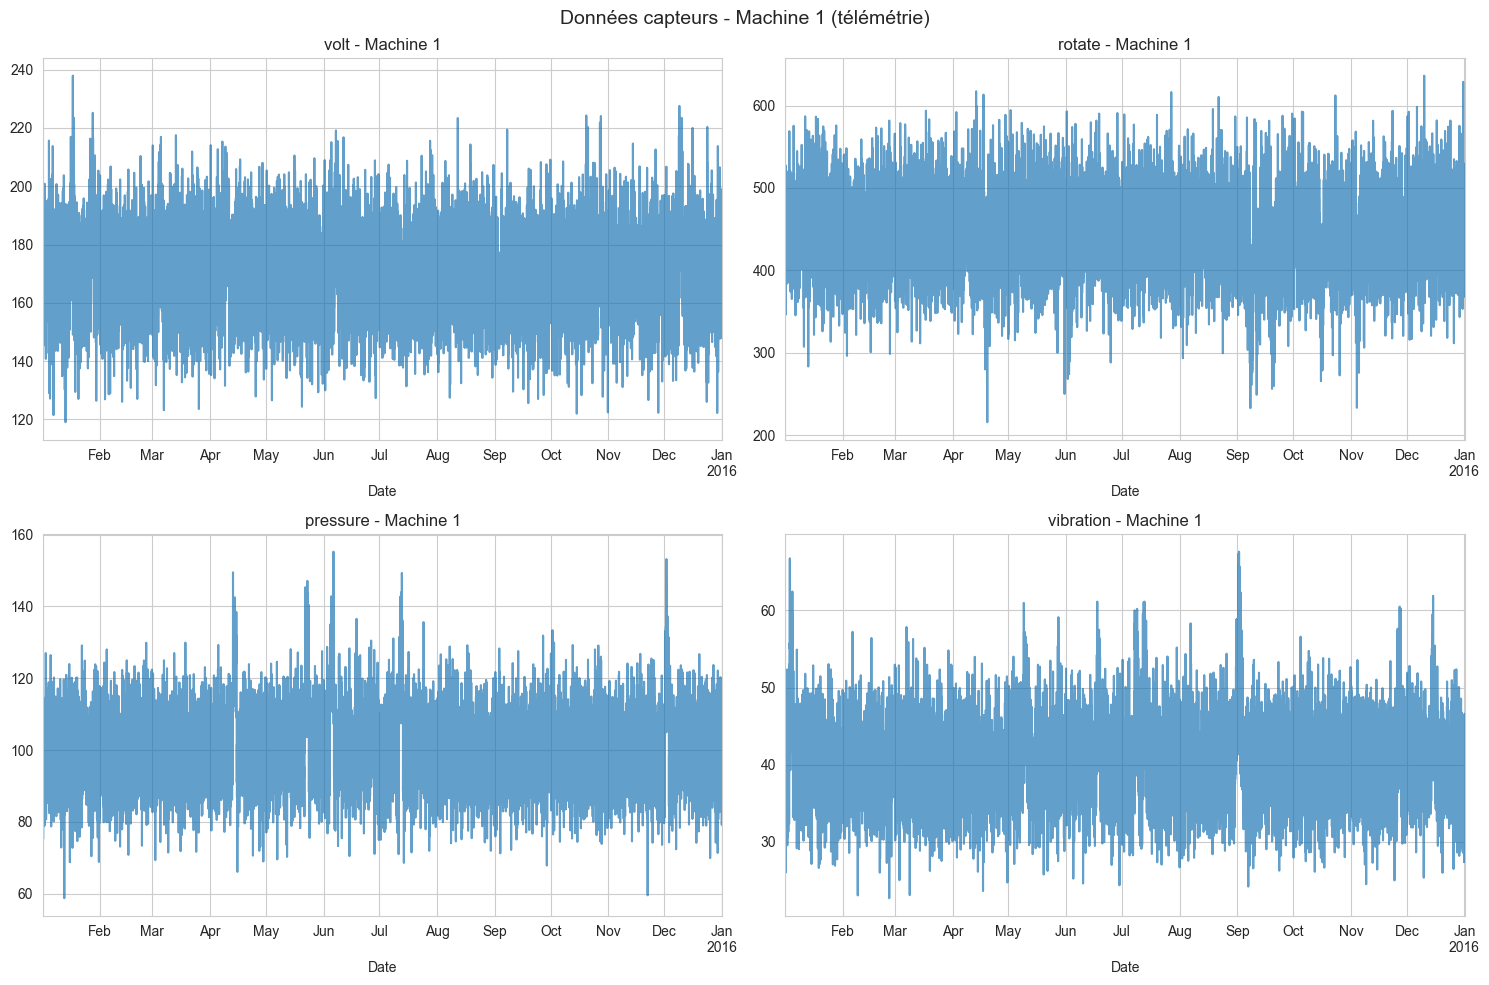

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
machine_data = telemetry[telemetry['machineID'] == 1].set_index('datetime')
for i, col in enumerate(['volt', 'rotate', 'pressure', 'vibration']):
    ax = axes[i // 2, i % 2]
    machine_data[col].plot(ax=ax, alpha=0.7)
    ax.set_title(f'{col} - Machine 1')
    ax.set_xlabel('Date')
plt.suptitle('Données capteurs - Machine 1 (télémétrie)', fontsize=14)
plt.tight_layout()
plt.show()

In [8]:
print('=== Distribution des pannes par composant ===')
print(failures['failure'].value_counts())
print(f'\n=== Distribution des erreurs ===')
print(errors['errorID'].value_counts())
print(f'\n=== Distribution des modèles de machines ===')
print(machines['model'].value_counts())

=== Distribution des pannes par composant ===
failure
comp2    259
comp1    192
comp4    179
comp3    131
Name: count, dtype: int64

=== Distribution des erreurs ===
errorID
error1    1010
error2     988
error3     838
error4     727
error5     356
Name: count, dtype: int64

=== Distribution des modèles de machines ===
model
model3    35
model4    32
model2    17
model1    16
Name: count, dtype: int64


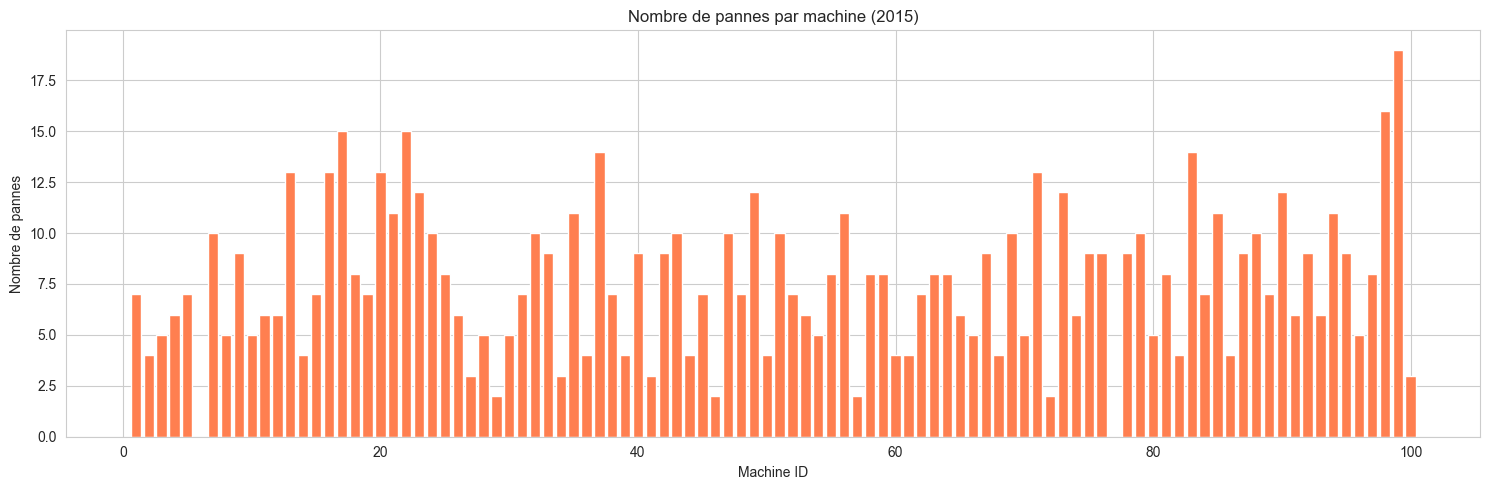

In [9]:
failures_by_machine = failures.groupby('machineID').size().reset_index(name='nb_pannes')
fig, ax = plt.subplots(figsize=(15, 5))
ax.bar(failures_by_machine['machineID'], failures_by_machine['nb_pannes'], color='coral')
ax.set_xlabel('Machine ID')
ax.set_ylabel('Nombre de pannes')
ax.set_title('Nombre de pannes par machine (2015)')
plt.tight_layout()
plt.show()

## 3. Dataset préparé (après feature engineering)

Vérification du dataset final après le pipeline de préparation.

In [10]:
prepared = pd.read_csv(PROCESSED_DIR / 'mecha_ai4i_prepared.csv')
print(f'Shape: {prepared.shape}')
print(f'\nNouvelles colonnes ajoutées:')
print([c for c in prepared.columns if c not in ai4i.columns])
prepared.head()

Shape: (10000, 19)

Nouvelles colonnes ajoutées:
['record_id', 'product_id', 'quality_type', 'air_temp_k', 'process_temp_k', 'rotational_speed_rpm', 'torque_nm', 'tool_wear_min', 'machine_failure', 'tool_wear_failure', 'heat_dissipation_failure', 'power_failure', 'overstrain_failure', 'random_failure', 'air_temp_c', 'process_temp_c', 'temp_diff', 'power_w', 'torque_speed_ratio']


,record_id,product_id,quality_type,air_temp_k,process_temp_k,rotational_speed_rpm,torque_nm,tool_wear_min,machine_failure,tool_wear_failure,heat_dissipation_failure,power_failure,overstrain_failure,random_failure,air_temp_c,process_temp_c,temp_diff,power_w,torque_speed_ratio
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0,24.95,35.45,10.5,6951.590560,0.027595
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0,25.05,35.55,10.5,6826.722724,0.032884
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0,24.95,35.35,10.4,7749.387543,0.032977
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0,25.05,35.45,10.4,5927.504659,0.027565
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0,25.05,35.55,10.5,5897.816608,0.028409


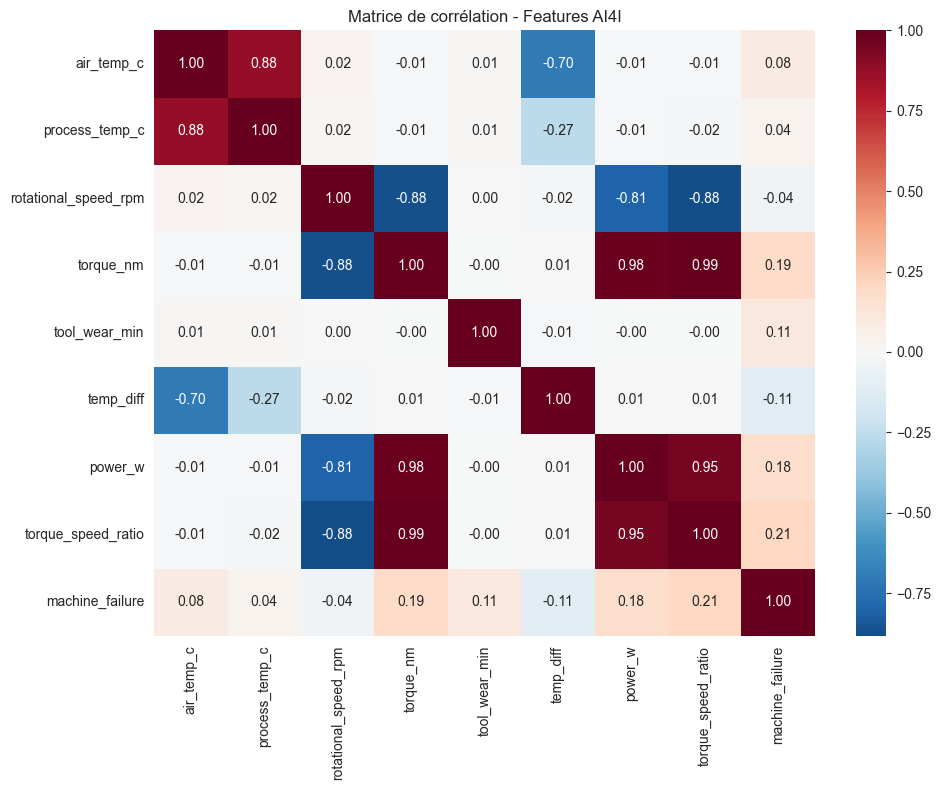

In [11]:
corr = prepared[['air_temp_c', 'process_temp_c', 'rotational_speed_rpm',
                  'torque_nm', 'tool_wear_min', 'temp_diff', 'power_w',
                  'torque_speed_ratio', 'machine_failure']].corr()
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, ax=ax)
ax.set_title('Matrice de corrélation - Features AI4I')
plt.tight_layout()
plt.show()